# Task 02 - EDA opcional: cenários de uso do FlowCarreiras

Este notebook utiliza **1.000 perfis totalmente fictícios**, construídos a partir das relações observadas nas 21 respostas reais da pesquisa do Grupo 11 e dos campos existentes no FlowCarreiras.

Objetivo: explorar perguntas diretamente relacionadas ao produto, como onboarding, portfólio, oportunidades, mentoria, prontidão e risco de estagnação.

> Este notebook é opcional. Seus resultados representam cenários de teste e não uso real do aplicativo. Se dados simulados não forem aceitos, ele pode ser removido sem afetar os notebooks 01, 02 e 03 ou a análise principal com dados reais.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 80)

DATA_PATH = Path("../data/external/flowcarreiras_artistas_simulados_recife.csv")
df = pd.read_csv(DATA_PATH)

print(f"Perfis simulados: {len(df):,}")
print(f"Colunas: {df.shape[1]}")
print(f"Cidades: {df['cidade'].unique().tolist()}")
df.head(3)

Perfis simulados: 1,000
Colunas: 61
Cidades: ['Recife']


,artista_id,nome_ficticio,cidade,uf,perfil_simulado,area_artistica_principal,faixa_etaria,tempo_atuacao_faixa,situacao_profissional,formalizado_mei_cnpj,sentimento_carreira,dificuldade_dependencia_algoritmo_1a5,dificuldade_apresentacao_profissional_1a5,dificuldade_converter_contatos_1a5,dificuldade_precificacao_1a5,dificuldade_inscricao_editais_1a5,concorda_dependencia_algoritmo_divulgacao_1a5,concorda_dificuldade_apresentacao_divulgacao_1a5,concorda_dificuldade_converter_contatos_divulgacao_1a5,plataformas_divulgacao,quantidade_plataformas_divulgacao,frequencia_organizacao_portfolio,possui_portfolio_digital_organizado,dispositivo_principal,qualidade_internet,barreiras_adocao_aplicativo,quantidade_barreiras_adocao,acesso_mentoria,interesse_em_mentoria,apoios_mentoria_desejados,intencao_uso_flowcarreiras,data_cadastro_simulada,ativo_no_app,bio_preenchida,foto_perfil_preenchida,quantidade_links_externos,necessidades_identificadas_pesquisa,quantidade_necessidades_identificadas,tags_necessidade,quantidade_tags_necessidade,tags_expertise,quantidade_tags_expertise,onboarding_concluido,percentual_completude_perfil,total_obras,obras_publicadas,obras_rascunho,portfolio_publico_ativo,dias_sem_atualizar_portfolio,receber_notificacoes_oportunidades,oportunidades_visualizadas_90d,oportunidades_salvas_90d,candidaturas_oportunidades_90d,perfil_mentor_configurado,disponivel_para_mentorar,mentorias_solicitadas,mentorias_concluidas,nivel_visibilidade_no_app,pronto_para_oportunidades,risco_estagnacao,url_publica_ficticia
0,FCR-0001,Renata Teixeira Carvalho,Recife,PE,True,Danca / Performance,(18-24),1 a 3 anos,Atuo de forma completamente informal (sem CNPJ...,False,"Consegue se sustentar, mas poderia avancar com...",5,5,1,1,5,1,1,1,Outra plataforma,1,toda semana,True,Smartphone (celular),"Boa, raramente tenho problemas de velocidade o...",Não vejo utilidade clara para o mim,1,"Sim, informalmente (um artista mais experiente...",True,"Orientação financeira (precificação, fluxo de ...","Sim, com certeza, faz falta algo assim",2025-10-04 09:52:00,False,True,True,3,fortalecimento de portfolio|divulgacao sem dep...,7,networking e acesso ao mercado|inscricao em ed...,6,performance|minimalista,2,False,100,12,11,1,True,5,True,1,0,0,False,False,3,0,alta,False,alto,/artistas/renata-teixeira-carvalho-0001
1,FCR-0002,Vinicius Santana Dias,Recife,PE,True,Escrita / Literatura / Poesia,45+,8 a 15 anos,Atuo de forma completamente informal (sem CNPJ...,False,"Tem talento e producao, mas falta estrutura pa...",3,3,2,1,3,3,3,2,Instagram|Facebook,2,Às vezes (a cada 2 a 6 meses),True,Smartphone (celular),"Boa, raramente tenho problemas de velocidade o...",Interface confusa ou difícil de entender|Não v...,2,"Não, mas tenho muito interesse em ter acesso a...",True,"Networking com produtores, curadores e empresa...","Talvez, dependeria de como funciona na prática",2025-09-08 13:06:00,False,True,False,0,fortalecimento de portfolio|inscricao em edita...,5,fortalecimento de portfolio|inscricao em edita...,5,poesia|revisao textual|abstrato,3,False,85,8,6,2,True,176,True,6,3,1,True,True,3,1,media,True,medio,/artistas/vinicius-santana-dias-0002
2,FCR-0003,Helena Lopes Monteiro,Recife,PE,True,Música,45+,Mais de 15 anos,"Tenho MEI ou CNPJ, mas ainda vivo de outra ren...",True,"Tem talento e producao, mas falta estrutura pa...",3,3,3,1,3,3,3,3,Instagram|Facebook|YouTube,3,Regularmente (ao menos uma vez por mês),True,Computador ou notebook,"Boa, raramente tenho problemas de velocidade o...",Cadastro muito longo ou que pede muitos docume...,3,"Não, mas tenho muito interesse em ter acesso a...",True,"Orientação jurídica (contratos, direitos autor...","Sim, com certeza, faz falta algo assim",2025-10-13 10:58:00,True,True,True,1,fortalecimento de portfolio|networking e acess...,5,fortalecimento de portfolio|networking e acess...,5,producao musical|performance ao vivo|composica...,4,True,100,12,10,2,True,35,True,5,4,1,False,False,1,0,alta,True,baixo,/artistas/helena-lopes-monteiro-0003

## 1. Quais dores o FlowCarreiras deve priorizar?

Esta seção compara dificuldades profissionais e necessidades identificadas. A pergunta não é apenas “quais categorias aparecem?”, mas **quais funcionalidades e conteúdos devem receber prioridade no produto?**

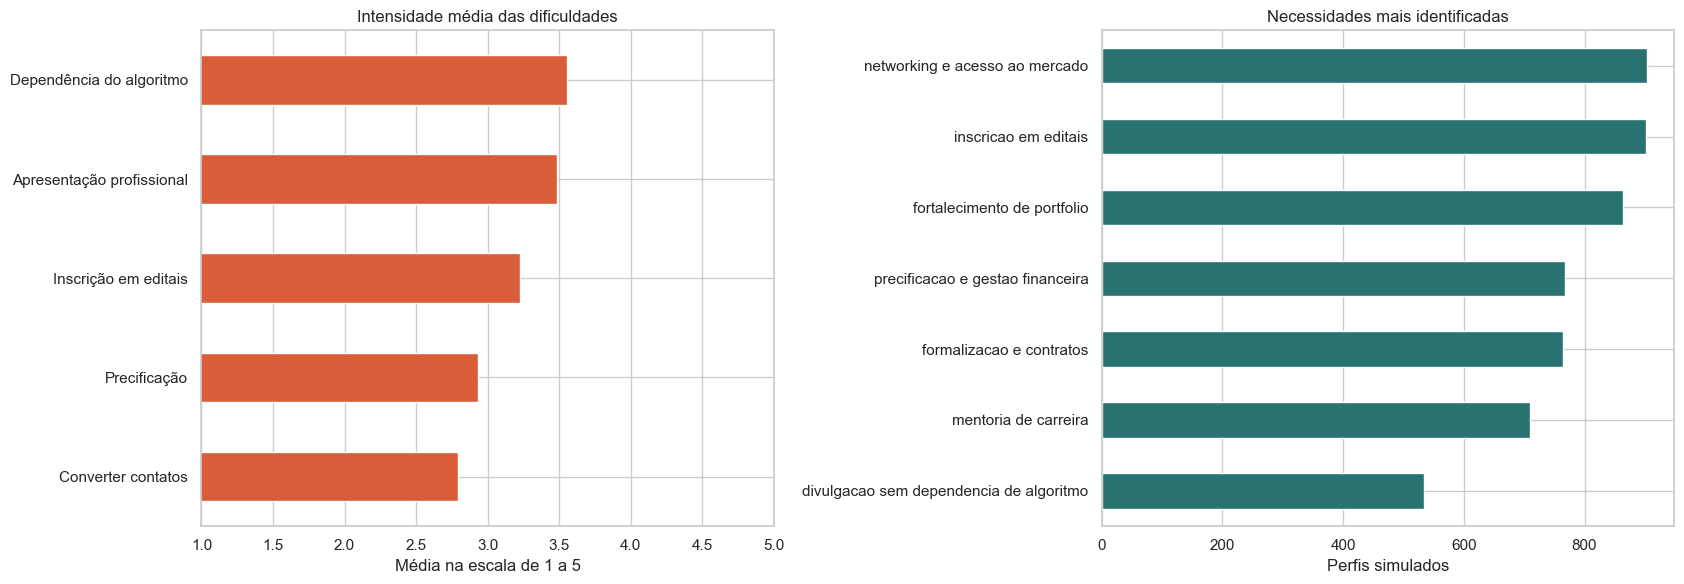

In [2]:
dificuldades = {
    "Dependência do algoritmo": "dificuldade_dependencia_algoritmo_1a5",
    "Apresentação profissional": "dificuldade_apresentacao_profissional_1a5",
    "Converter contatos": "dificuldade_converter_contatos_1a5",
    "Precificação": "dificuldade_precificacao_1a5",
    "Inscrição em editais": "dificuldade_inscricao_editais_1a5",
}

media_dificuldades = pd.Series({
    nome: df[coluna].mean() for nome, coluna in dificuldades.items()
}).sort_values()

necessidades = (
    df["necessidades_identificadas_pesquisa"].dropna()
    .str.split("|", regex=False).explode().str.strip()
    .value_counts().head(10).sort_values()
)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
media_dificuldades.plot.barh(ax=axes[0], color="#D95D39")
axes[0].set(title="Intensidade média das dificuldades", xlabel="Média na escala de 1 a 5", ylabel="")
axes[0].set_xlim(1, 5)

necessidades.plot.barh(ax=axes[1], color="#287271")
axes[1].set(title="Necessidades mais identificadas", xlabel="Perfis simulados", ylabel="")
plt.tight_layout()
plt.show()

**Decisão de produto:** as necessidades mais frequentes podem orientar atalhos do onboarding, categorias de mentoria, conteúdos de apoio e filtros de oportunidades. As intensidades ajudam a priorizar o que deve aparecer primeiro, mas não substituem validação com usuários reais.

## 2. O onboarding progressivo reduz barreiras?

Perguntas:

- Quais barreiras de adoção aparecem com maior frequência?
- Perfis que rejeitam cadastro longo apresentam menor conclusão do onboarding?
- Quais campos ainda ficam sem preenchimento?

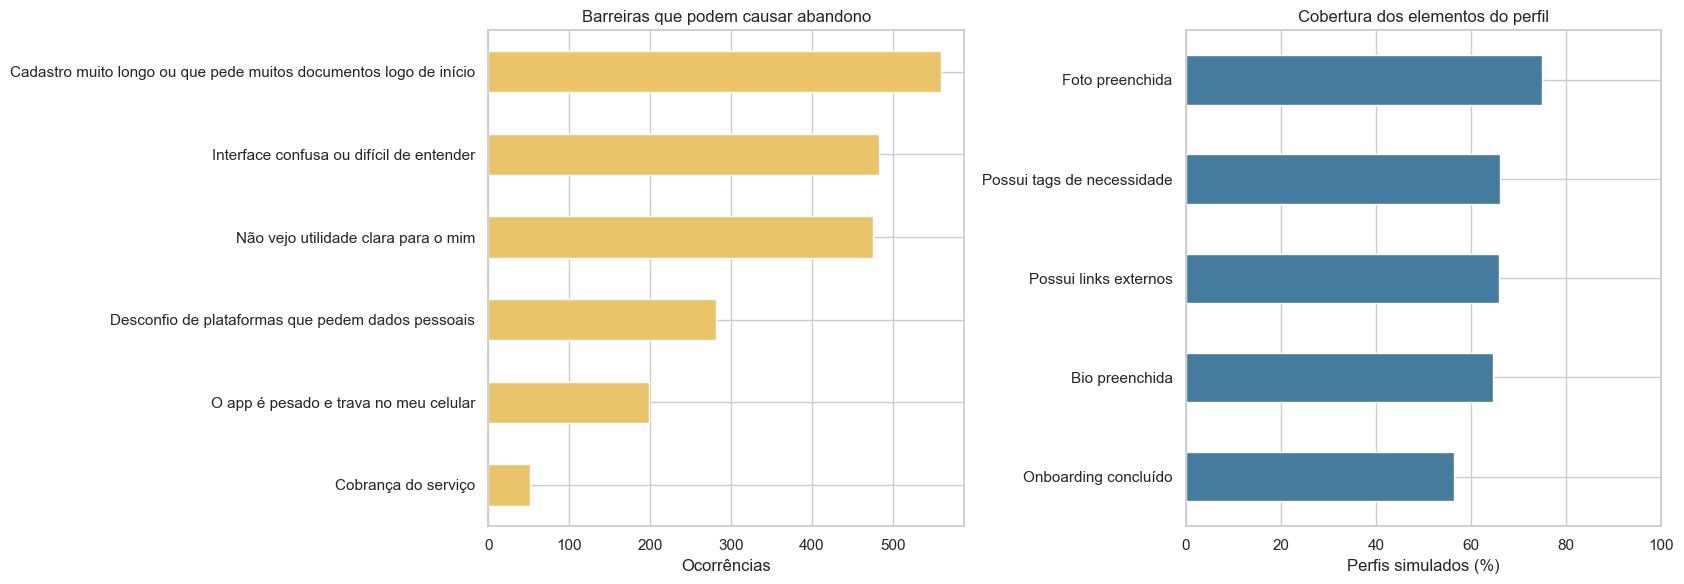

onboarding_concluido,False,True
barreira_cadastro_longo,,
False,44.3,55.7
True,43.0,57.0


In [3]:
barreiras = (
    df["barreiras_adocao_aplicativo"].dropna()
    .str.split("|", regex=False).explode().str.strip()
    .value_counts().sort_values()
)

campos_perfil = pd.Series({
    "Bio preenchida": df["bio_preenchida"].mean() * 100,
    "Foto preenchida": df["foto_perfil_preenchida"].mean() * 100,
    "Possui links externos": df["quantidade_links_externos"].gt(0).mean() * 100,
    "Possui tags de necessidade": df["quantidade_tags_necessidade"].gt(0).mean() * 100,
    "Onboarding concluído": df["onboarding_concluido"].mean() * 100,
}).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
barreiras.plot.barh(ax=axes[0], color="#E9C46A")
axes[0].set(title="Barreiras que podem causar abandono", xlabel="Ocorrências", ylabel="")
campos_perfil.plot.barh(ax=axes[1], color="#457B9D")
axes[1].set(title="Cobertura dos elementos do perfil", xlabel="Perfis simulados (%)", ylabel="")
axes[1].set_xlim(0, 100)
plt.tight_layout()
plt.show()

df["barreira_cadastro_longo"] = df["barreiras_adocao_aplicativo"].str.contains("Cadastro muito longo", na=False)
pd.crosstab(df["barreira_cadastro_longo"], df["onboarding_concluido"], normalize="index").mul(100).round(1)

**Decisão de produto:** cadastro longo, interface confusa e utilidade pouco clara indicam que o onboarding deve mostrar valor rapidamente, permitir pular etapas e funcionar bem em celular. A comparação com conclusão do onboarding é hipotética e deve ser validada após instrumentação real.

## 3. O perfil estruturado ajuda a construir portfólio?

Perguntas:

- Perfis mais completos publicam mais obras?
- Quem não possui portfólio organizado permanece mais tempo sem atualizar?
- Quais grupos possuem portfólio público ativo?

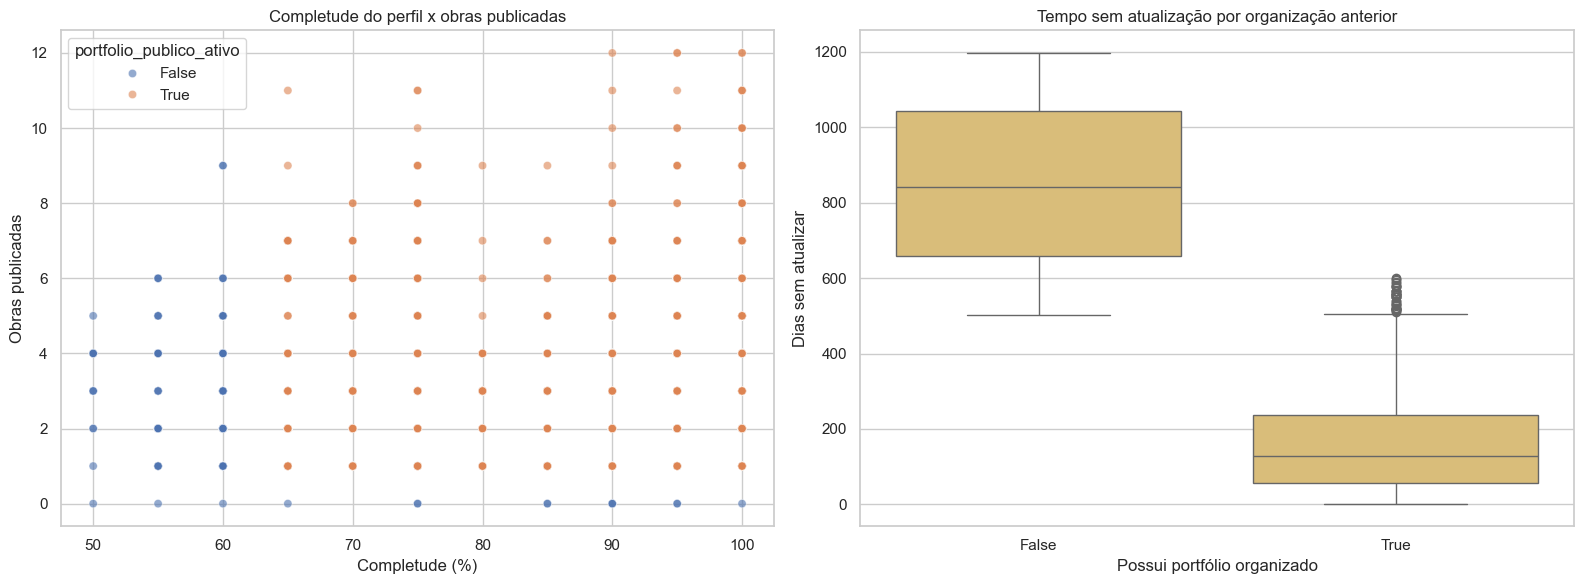

,artistas,completude_mediana,obras_publicadas_mediana,dias_sem_atualizar_mediana
portfolio_publico_ativo,,,,
False,101,60.0,3.0,609.0
True,899,90.0,3.0,185.0


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=df, x="percentual_completude_perfil", y="obras_publicadas",
    hue="portfolio_publico_ativo", alpha=.6, ax=axes[0]
)
axes[0].set(title="Completude do perfil x obras publicadas", xlabel="Completude (%)", ylabel="Obras publicadas")

sns.boxplot(
    data=df, x="possui_portfolio_digital_organizado",
    y="dias_sem_atualizar_portfolio", ax=axes[1], color="#E9C46A"
)
axes[1].set(title="Tempo sem atualização por organização anterior", xlabel="Possui portfólio organizado", ylabel="Dias sem atualizar")
plt.tight_layout()
plt.show()

df.groupby("portfolio_publico_ativo").agg(
    artistas=("artista_id", "count"),
    completude_mediana=("percentual_completude_perfil", "median"),
    obras_publicadas_mediana=("obras_publicadas", "median"),
    dias_sem_atualizar_mediana=("dias_sem_atualizar_portfolio", "median"),
).round(1)

**Decisão de produto:** a jornada deve conduzir o artista de perfil preenchido para primeira obra e portfólio público. Perfis parados podem receber lembretes ou sugestões específicas, evitando mensagens genéricas.

## 4. Onde está o gargalo do portal de oportunidades?

O funil permite identificar a redução entre visualizar, salvar e candidatar-se. Como os números são simulados, ele serve para testar indicadores e o formato do futuro dashboard.

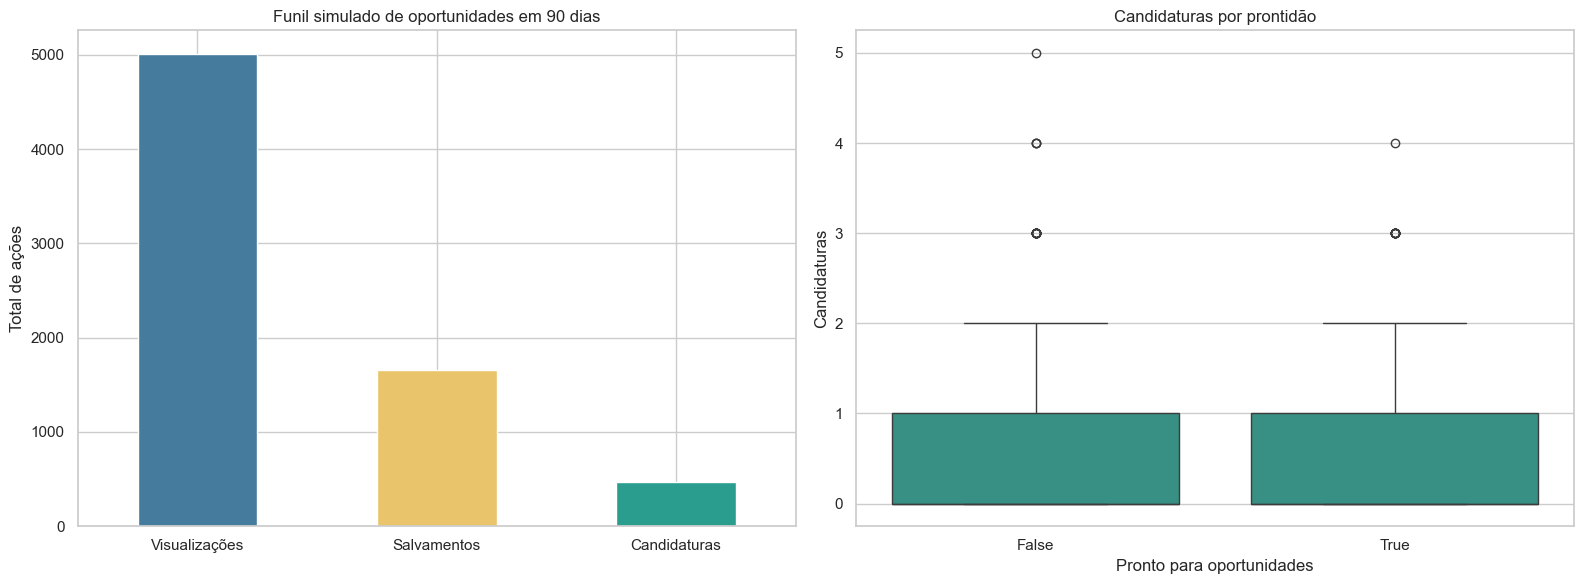

Conversão visualização → salvamento    33.1
Conversão salvamento → candidatura     28.5
dtype: float64

In [5]:
funil = pd.Series({
    "Visualizações": df["oportunidades_visualizadas_90d"].sum(),
    "Salvamentos": df["oportunidades_salvas_90d"].sum(),
    "Candidaturas": df["candidaturas_oportunidades_90d"].sum(),
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
funil.plot.bar(ax=axes[0], color=["#457B9D", "#E9C46A", "#2A9D8F"])
axes[0].set(title="Funil simulado de oportunidades em 90 dias", xlabel="", ylabel="Total de ações")
axes[0].tick_params(axis="x", rotation=0)

sns.boxplot(
    data=df, x="pronto_para_oportunidades",
    y="candidaturas_oportunidades_90d", ax=axes[1], color="#2A9D8F"
)
axes[1].set(title="Candidaturas por prontidão", xlabel="Pronto para oportunidades", ylabel="Candidaturas")
plt.tight_layout()
plt.show()

pd.Series({
    "Conversão visualização → salvamento": funil["Salvamentos"] / funil["Visualizações"] * 100,
    "Conversão salvamento → candidatura": funil["Candidaturas"] / funil["Salvamentos"] * 100,
}).round(1)

**Decisão de produto:** o dashboard real deve acompanhar visualizações, salvamentos, acessos externos e candidaturas. Se o maior abandono ocorrer antes da candidatura, o produto pode oferecer orientação para editais, checklist ou mentoria relacionada.

## 5. Há equilíbrio entre demanda e oferta de mentoria?

Perguntas:

- Quantos demonstram interesse?
- Quantos estão disponíveis para mentorar?
- Quais apoios são mais desejados?
- Experiência está associada à oferta potencial?

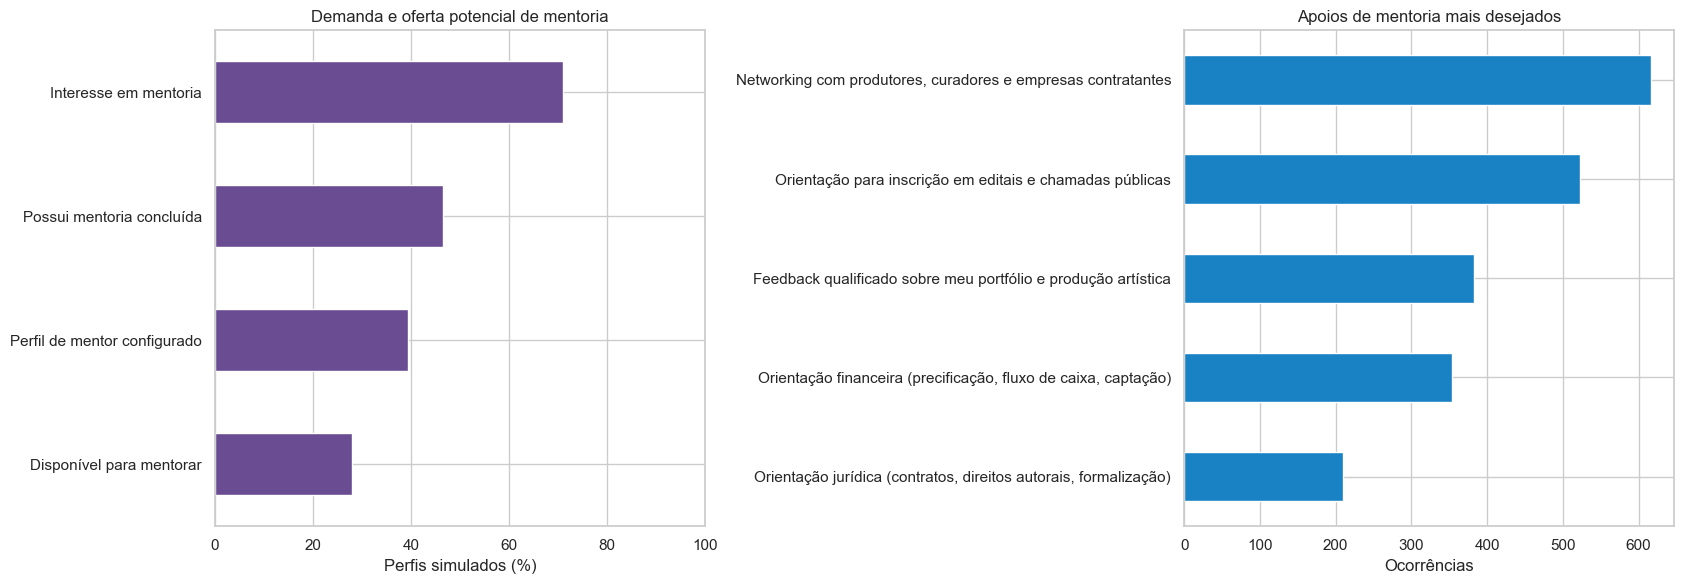

disponivel_para_mentorar,False,True
tempo_atuacao_faixa,,
1 a 3 anos,100.0,0.0
4 a 7 anos,100.0,0.0
8 a 15 anos,66.4,33.6
Mais de 15 anos,53.3,46.7
Menos de 1 ano,100.0,0.0


In [6]:
apoios = (
    df["apoios_mentoria_desejados"].dropna()
    .str.split("|", regex=False).explode().str.strip()
    .value_counts().sort_values()
)

mentoria_indicadores = pd.Series({
    "Interesse em mentoria": df["interesse_em_mentoria"].mean() * 100,
    "Perfil de mentor configurado": df["perfil_mentor_configurado"].mean() * 100,
    "Disponível para mentorar": df["disponivel_para_mentorar"].mean() * 100,
    "Possui mentoria concluída": df["mentorias_concluidas"].gt(0).mean() * 100,
}).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
mentoria_indicadores.plot.barh(ax=axes[0], color="#6A4C93")
axes[0].set(title="Demanda e oferta potencial de mentoria", xlabel="Perfis simulados (%)", ylabel="")
axes[0].set_xlim(0, 100)
apoios.plot.barh(ax=axes[1], color="#1982C4")
axes[1].set(title="Apoios de mentoria mais desejados", xlabel="Ocorrências", ylabel="")
plt.tight_layout()
plt.show()

pd.crosstab(df["tempo_atuacao_faixa"], df["disponivel_para_mentorar"], normalize="index").mul(100).round(1)

**Decisão de produto:** se a procura superar a oferta, o FlowCarreiras pode recrutar mentores em áreas específicas, permitir modalidades diferentes e destacar apoios com maior demanda. O match futuro deve comparar necessidades e expertise, não popularidade.

## 6. Quem precisa de apoio para avançar?

Prontidão e risco de estagnação são variáveis derivadas para testar uma jornada orientada. Elas não devem ser exibidas como rótulos públicos nem usadas para decidir automaticamente sobre pessoas reais.

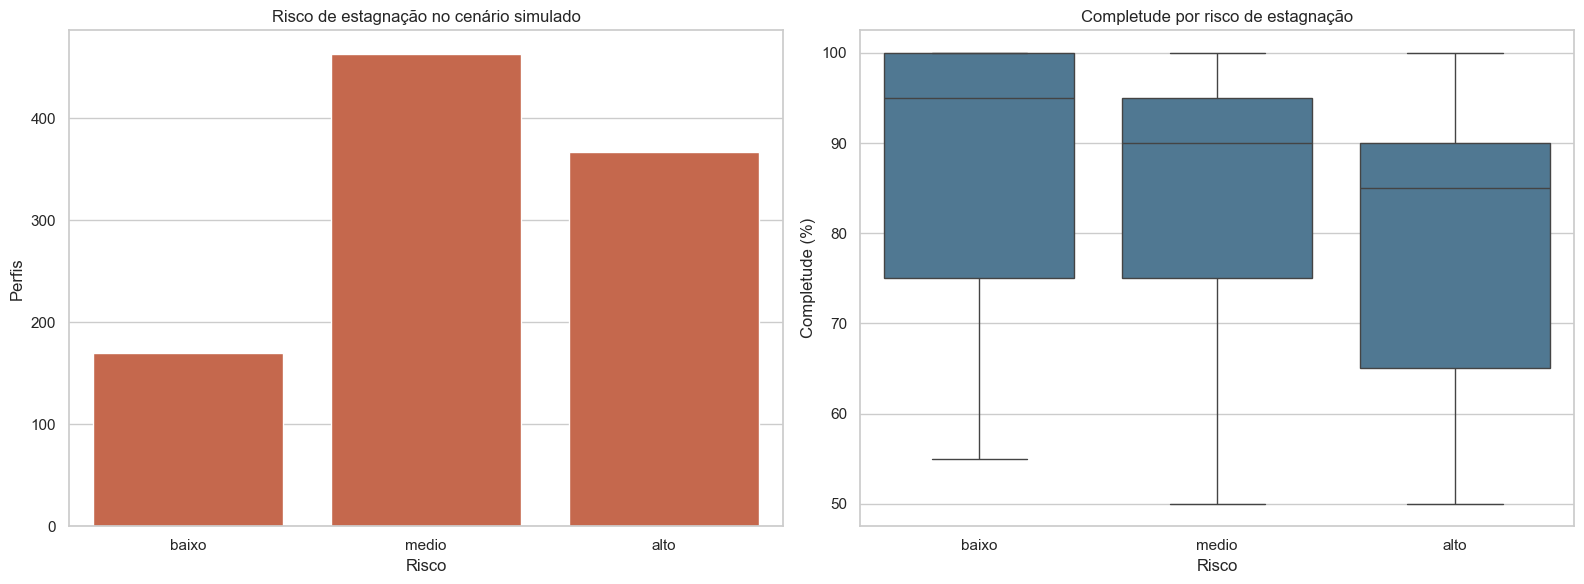

,artistas,ativos_pct,onboarding_pct,obras_publicadas_mediana,candidaturas_media
risco_estagnacao,,,,,
alto,367,52.9,34.1,3.0,0.1
baixo,170,100.0,72.4,6.0,1.1
medio,463,96.1,68.3,3.0,0.5


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df, x="risco_estagnacao", order=["baixo", "medio", "alto"], ax=axes[0], color="#D95D39")
axes[0].set(title="Risco de estagnação no cenário simulado", xlabel="Risco", ylabel="Perfis")

sns.boxplot(
    data=df, x="risco_estagnacao", y="percentual_completude_perfil",
    order=["baixo", "medio", "alto"], ax=axes[1], color="#457B9D"
)
axes[1].set(title="Completude por risco de estagnação", xlabel="Risco", ylabel="Completude (%)")
plt.tight_layout()
plt.show()

df.groupby("risco_estagnacao").agg(
    artistas=("artista_id", "count"),
    ativos_pct=("ativo_no_app", "mean"),
    onboarding_pct=("onboarding_concluido", "mean"),
    obras_publicadas_mediana=("obras_publicadas", "median"),
    candidaturas_media=("candidaturas_oportunidades_90d", "mean"),
).assign(
    ativos_pct=lambda x: x["ativos_pct"] * 100,
    onboarding_pct=lambda x: x["onboarding_pct"] * 100,
).round(1)

**Decisão de produto:** o objetivo não é criar um ranking de artistas, mas identificar ações úteis: concluir perfil, publicar primeira obra, encontrar oportunidade adequada ou receber mentoria. Qualquer intervenção real precisa ser transparente e validada com usuários.

## 7. Segmentos para jornadas diferentes

Esta visão cruza prontidão, mentoria e organização do portfólio para pensar em jornadas de produto, não para classificar mérito artístico.

In [8]:
segmentos = pd.crosstab(
    [df["pronto_para_oportunidades"], df["possui_portfolio_digital_organizado"]],
    df["interesse_em_mentoria"],
    margins=True
)
segmentos

interesse_em_mentoria                                          False  True  \
pronto_para_oportunidades possui_portfolio_digital_organizado                
False                     False                                  149   134   
                          True                                    29   367   
True                      False                                   40     8   
                          True                                    72   201   
All                                                              290   710   

interesse_em_mentoria                                           All  
pronto_para_oportunidades possui_portfolio_digital_organizado        
False                     False                                 283  
                          True                                  396  
True                      False                                  48  
                          True                                  273  
All                                                            1000

### Jornadas hipotéticas sugeridas

- **Perfil incompleto e sem portfólio:** onboarding guiado e primeira obra.
- **Portfólio ativo, mas pouca candidatura:** orientação sobre editais e oportunidades.
- **Interesse em mentoria:** match por necessidade e expertise.
- **Pronto para oportunidades:** recomendações e notificações relevantes.
- **Experiente e disponível:** configuração simplificada para atuar como mentor.

Essas jornadas devem ser testadas com dados reais de uso e entrevistas.

## Principais insights opcionais para o FlowCarreiras

1. As dores e necessidades podem orientar categorias, conteúdos e filtros do produto.
2. Cadastro longo, interface confusa e utilidade pouco clara devem ser tratados no onboarding.
3. A jornada principal deve conectar completude, primeira obra e portfólio público.
4. O funil de oportunidades precisa registrar visualizações, salvamentos e candidaturas reais.
5. A oferta de mentoria deve ser comparada continuamente com a demanda por apoio.
6. Prontidão e risco só fazem sentido como instrumentos privados de apoio, nunca como ranking público.
7. Todas as conclusões deste notebook são hipóteses sobre cenários simulados.